# Resumen documento

A lo largo de este documento simula la solución al **Minimal Maximal Matching** de varios grafos de ejemplo

In [110]:
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
import numpy as np

output_notebook()

if not os.path.isdir("data"):
    os.mkdir("data")

Loading BokehJS ...

## Geometría 1: 4 vértices en línea (3 aristas en línea)

In [111]:
# 1. Geometría (Grafo de 4 vértices -> 3 aristas/átomos)
# Átomo 0 (e1): x=0, y=0
# Átomo 1 (e2): x=0, y=5.0
# Átomo 2 (e3): x=0, y=10.0
coordenadas = [(0.0, 0.0), (0.0, 5.0), (0.0, 10.0)] 
geometria = ListOfLocations(coordenadas)
#geometria.show()

# 2. Parámetros Físicos
delta_end = 8.0
omega_max = 3.3
sweep_time = 2.4

C6 = 2 * np.pi * 862690
Rb = (C6 / omega_max) ** (1/6)
print(f"Radio de Bloqueo (Rb): {Rb:.2f} um")
# Verificación de distancias:
# Distancia 0-1 = 5.0 um (< Rb, hay bloqueo)
# Distancia 1-2 = 5.0 um (< Rb, hay bloqueo)
# Distancia 0-2 = 10.0 um (> Rb, no hay bloqueo)


# 3. Formas de onda del pulso láser
durations = [0.8, sweep_time, 0.8]
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

# 4. Desintonización Local (Modulación Espacial)
# Las aristas de los extremos (e1, e3) tienen una topología diferente 
# a la arista central (e2). Reflejamos esto ajustando los factores de escala.
escala_detuning = [1.0, 0.65, 1.0]

# 5. Construcción de la Secuencia
prog = (
    geometria
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
    # Se reemplaza .uniform por .scale() para aplicar los coeficientes locales
    .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)
)

emu_prog = prog.bloqade.python().run(shots=30000)

emu_prog.report().show()

Radio de Bloqueo (Rb): 10.86 um
0.0 0.0 0.0 10000000.0


In [1]:
# --- SECCIÓN: Mapeo explícito de las condiciones lógicas (A, B, C) al Hardware ---

from bloqade.analog.atom_arrangement import ListOfLocations
import numpy as np

# 1. PARÁMETROS FÍSICOS Y CONDICIÓN A (Validez del Matching)
omega_max = 3.3  # rad/us.
C6 = 2 * np.pi * 862690
Rb = (C6 / omega_max) ** (1/6) # Rb ~ 10.86 um

# La Condición A exige que aristas incidentes en el mismo vértice clásico no se exciten a la vez.
# Físicamente, colocamos los átomos a una distancia d < Rb.
d = 5.0 # 5.0 < 10.86. El bloqueo de Rydberg actuará como la penalización 'A'.
coordenadas = [(0.0, 0.0), (0.0, d), (0.0, 2*d)] 
geometria = ListOfLocations(coordenadas)

# 2. EVOLUCIÓN ADIABÁTICA
# El sistema se inicializa en el estado fundamental trivial (todos en |g>) mediante
# un detuning muy negativo, y se barre lentamente hacia valores positivos.
delta_end = 8.0
sweep_time = 2.4
durations = [0.8, sweep_time, 0.8]
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

# 3. CONDICIONES B (Maximalidad) y C (Minimalidad) -> DESINTONIZACIÓN LOCAL
# Al expandir analíticamente H_B y H_C, se generan términos lineales dependientes del grado clásico.
# En el hardware de Rydberg, esto se mapea al detuning local (\Delta_i).
# Un \Delta_i mayor favorece la excitación de ese átomo.
# 
# En este grafo en línea (e1 - e2 - e3):
# - Las soluciones maximales son excitar {e1, e3} o excitar {e2}.
# - La solución MINIMAL maximal es excitar solo {e2} (átomo central).
# Para forzar esto, el átomo central debe ser energéticamente más favorable. Le damos 
# todo el peso del láser (escala 1.0), y penalizamos los extremos (escala menor).
escala_detuning = [0.65, 1.0, 0.65] 

# 4. CONSTRUCCIÓN DE LA SECUENCIA
prog_explicativo = (
    geometria
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
    .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)
)

# Visualización de la modulación local (Opcional)
prog_explicativo.show()

emu_prog_explicativo = prog_explicativo.bloqade.python().run(shots=30000)
emu_prog_explicativo.report().show()

c:\Users\j.pena.riosalido\Documents\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


0.0 0.0 0.0 10000000.0


## Geometría 0: Ejemplo mínimo P3 — Derivación explícita de A, B, C

Grafo de 3 vértices en línea con 2 aristas → **2 átomos**.

```
v0 ---e01--- v1 ---e12--- v2
  átomo 0          átomo 1
```

El grado máximo es Δ=2 (vértice v1). Las soluciones MMM válidas son {e01} **o** {e12}.

### Expansión algebraica del Hamiltoniano de Lucas

Definimos yᵥ = Σ_{e∈∂v} xₑ (número de aristas coloreadas en v):
- y_v0 = x_e01
- y_v1 = x_e01 + x_e12
- y_v2 = x_e12

**H_A** (penaliza vértice con 2 aristas): solo existe el par (e01, e12) compartiendo v1:
$$H_A = A \cdot x_{e01} x_{e12}$$

**H_B** (penaliza aristas no cubiertas), expandiendo (1−yᵤ)(1−yᵥ) para cada arista:

$$H_B = B[(1-y_{v0})(1-y_{v1}) + (1-y_{v1})(1-y_{v2})]$$

Sustituyendo y usando que xₑ² = xₑ (binario):

$$H_B = B[2 - 2x_{e01} - 2x_{e12} + 2x_{e01}x_{e12}]$$

**H_C** (minimiza aristas): $H_C = C(x_{e01} + x_{e12})$

**Hamiltoniano total** (ignorando constantes):

$$H = \underbrace{(A + 2B)}_{\text{término } V_{ij}} x_{e01}x_{e12} + \underbrace{(-2B + C)}_{\text{término } {-\Delta_i}} (x_{e01} + x_{e12})$$

### Mapeo al Hamiltoniano de Rydberg

| Término físico | Expresión | Rol |
|---|---|---|
| $V_{01}$ | $A + 2B$ | Fijado por la distancia entre átomos: $d = (C_6/V_{01})^{1/6}$ |
| $\Delta_i$ | $2B - C$ | Igual para ambos átomos (grafo simétrico) |

**Condiciones sobre A, B, C:**
- Con Δ=2: la condición A > (Δ−2)B = 0 se satisface trivialmente con A > 0
- Debe cumplirse B > C > 0
- El detuning local Δᵢ = 2B−C > 0 queda garantizado automáticamente si B > C

In [113]:
## Geometría 0: P3 — Derivación explícita de condiciones lógicas

# ── 1. Parámetros A, B, C (A > 0, B > C > 0 // A > (D-2)B > (D-2)C) ──────────────────────
C6 = 2 * np.pi * 862690   # constante de Rydberg [rad/us * um^6]

x_values = [1.0, 1.5, 3]   # energía de penalización de grado (unidades relativas)

resultados = []

for x in x_values:
    A = 4
    B = 0.7   #0.5 energía de penalización de maximalidad 
    C = 0.2   # 0.2energía de minimización

    degree = 3
    print(f"\n--- Evaluando para A = {A} // (degree-2)*B = {(degree-2)*B} ) // B = {B}, C = {C} ---")

  
    if not (A > (degree-2)*B or B > C > 0):
    # Códigos ANSI: \033[91m (Rojo), \033[1m (Negrita), \033[0m (Resetear formato)
        ROJO_NEGRITA = '\033[1;91m'
        RESET = '\033[0m'

        print(f"{ROJO_NEGRITA}\n" + "="*60)
        print(" ⚠️ RESTRICCIÓN LÓGICA VIOLADA ⚠️ A > (D-2)*B ó B > C > 0")
        print("="*60)
        print(f" Condiciones requeridas: A > (D-2)*B  //  B > C > 0")
        print(f" Valores actuales   : A = {A}, B = {B}, C = {C}")
        print(" Resultado (D-2)*B       : El sistema priorizará reducir el tamaño")
        print("="*60 + f"{RESET}\n")

    # ── 2. Mapeo a parámetros físicos ─────────────────────────────────────────────
    # Término cuadrático: V_01 = A + 2B → fija la distancia entre átomos
    V_01 = A + 2 * B
    d_atomos = (C6 / x*V_01) ** (1/6)
    print(f"V_01 requerido : {V_01:.3f} rad/us")
    print(f"Distancia átomos: {d_atomos:.2f} um")

    # Término lineal: Delta_i = 2B - C (igual para ambos átomos por simetría del grafo)
    delta_local = 2 * B - C
    print(f"Detuning local requerido: {delta_local:.3f} rad/us")

    # ── 3. Geometría: 2 átomos separados d_atomos ─────────────────────────────────
    coordenadas = [(0.0, 0.0), (0.0, d_atomos)]
    geometria = ListOfLocations(coordenadas)
    #geometria.show()

    # ── 4. Waveforms ──────────────────────────────────────────────────────────────
    omega_max  = 3.3
    delta_end  = 8.0
    sweep_time = 3.0
    durations  = [0.8, sweep_time, 0.8]

    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

    # escala_detuning: cada átomo recibe escala_i * delta_end al final del barrido.
    # Queremos que ese valor sea delta_local, por tanto:
    escala = delta_local / delta_end
    escala_detuning = [escala, escala]   # simétrico: ambos átomos igual

    print(f"\nEscala de detuning aplicada: {escala:.4f}")
    print(f"Detuning efectivo al final : {escala * delta_end:.3f} rad/us  (objetivo: {delta_local:.3f})")

    # ── 5. Construcción de la secuencia ───────────────────────────────────────────
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)
    )

    emu_prog = prog.bloqade.python().run(shots=3000)

    emu_prog.report().show()


--- Evaluando para A = 4 // (degree-2)*B = 0.7 ) // B = 0.7, C = 0.2 ---
V_01 requerido : 5.400 rad/us
Distancia átomos: 17.56 um
Detuning local requerido: 1.200 rad/us

Escala de detuning aplicada: 0.1500
Detuning efectivo al final : 1.200 rad/us  (objetivo: 1.200)
0.0 0.0 0.0 17555157.573625524



--- Evaluando para A = 4 // (degree-2)*B = 0.7 ) // B = 0.7, C = 0.2 ---
V_01 requerido : 5.400 rad/us
Distancia átomos: 16.41 um
Detuning local requerido: 1.200 rad/us

Escala de detuning aplicada: 0.1500
Detuning efectivo al final : 1.200 rad/us  (objetivo: 1.200)
0.0 0.0 0.0 16408020.457325049



--- Evaluando para A = 4 // (degree-2)*B = 0.7 ) // B = 0.7, C = 0.2 ---
V_01 requerido : 5.400 rad/us
Distancia átomos: 14.62 um
Detuning local requerido: 1.200 rad/us

Escala de detuning aplicada: 0.1500
Detuning efectivo al final : 1.200 rad/us  (objetivo: 1.200)
0.0 0.0 0.0 14617884.39265135



B=0.30 | V_01=1.60 | d=12.26 um | Δ_local=0.40 | escala=0.050
  → P(éxito) = 20.67%  |  Distribución: {'00': 98, '01': 30, '10': 32, '11': 140}

B=0.50 | V_01=2.00 | d=11.81 um | Δ_local=0.80 | escala=0.100
  → P(éxito) = 39.67%  |  Distribución: {'00': 115, '01': 68, '10': 51, '11': 66}

B=0.80 | V_01=2.60 | d=11.30 um | Δ_local=1.40 | escala=0.175
  → P(éxito) = 44.33%  |  Distribución: {'00': 161, '01': 67, '10': 66, '11': 6}

B=1.20 | V_01=3.40 | d=10.81 um | Δ_local=2.20 | escala=0.275
  → P(éxito) = 40.67%  |  Distribución: {'00': 162, '01': 58, '10': 64, '11': 16}

B=1.80 | V_01=4.60 | d=10.28 um | Δ_local=3.40 | escala=0.425
  → P(éxito) = 72.67%  |  Distribución: {'00': 66, '01': 107, '10': 111, '11': 16}

   B  V_01      d_um  Delta_local  P_exito
0.3   1.6 12.255163          0.4 0.206667
0.5   2.0 11.807758          0.8 0.396667
0.8   2.6 11.302562          1.4 0.443333
1.2   3.4 10.808347          2.2 0.406667
1.8   4.6 10.277310          3.4 0.726667


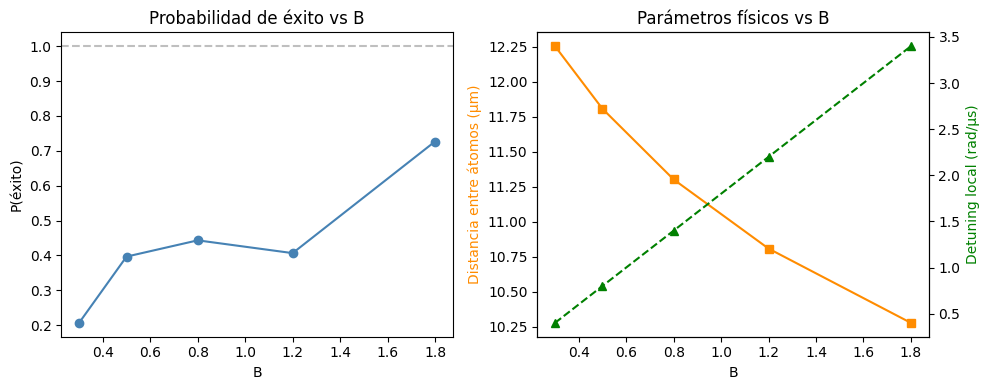

In [114]:
## Barrido sobre B — cómo afecta la penalización de maximalidad al resultado

import pandas as pd

# ── Parámetros fijos ───────────────────────────────────────────────────────────
C6        = 2 * np.pi * 862690
A         = 1.0
C_cost    = 0.2      # renombrado para no colisionar con C6
omega_max = 3.3
delta_end = 8.0
sweep_time = 3.0
durations  = [0.8, sweep_time, 0.8]
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]

# ── Valores de B a explorar (debe cumplir B > C_cost) ─────────────────────────
B_values = [0.3, 0.5, 0.8, 1.2, 1.8]

resultados = []

for B in B_values:
    # Verificación de jerarquía
    if not (A > 0 and B > C_cost > 0):
        print(f"B={B} viola la jerarquía, saltando.")
        continue

    # Mapeo a parámetros físicos
    V_01        = A + 2 * B
    d_atomos    = (C6 / V_01) ** (1/6)
    delta_local = 2 * B - C_cost
    escala      = delta_local / delta_end

    print(f"\nB={B:.2f} | V_01={V_01:.2f} | d={d_atomos:.2f} um | Δ_local={delta_local:.2f} | escala={escala:.3f}")

    # Geometría y secuencia
    geometria = ListOfLocations([(0.0, 0.0), (0.0, d_atomos)])
    rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale([escala, escala]).piecewise_linear(durations, rabi_detuning_values)
    )

    # Simulación
    report = prog.bloqade.python().run(shots=300).report()
    counts = report.counts()[0]   # dict bitstring -> nº ocurrencias

    # Soluciones MMM válidas para P3: "10" o "01" (exactamente una arista)
    n_correcto = counts.get("10", 0) + counts.get("01", 0)
    n_total    = sum(counts.values())
    prob_exito = n_correcto / n_total

    print(f"  → P(éxito) = {prob_exito:.2%}  |  Distribución: {dict(sorted(counts.items()))}")
    resultados.append({"B": B, "V_01": V_01, "d_um": d_atomos,
                       "Delta_local": delta_local, "P_exito": prob_exito})

# ── Resumen ────────────────────────────────────────────────────────────────────
df = pd.DataFrame(resultados)
print("\n", df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(df["B"], df["P_exito"], "o-", color="steelblue")
axes[0].set_xlabel("B")
axes[0].set_ylabel("P(éxito)")
axes[0].set_title("Probabilidad de éxito vs B")
axes[0].axhline(1.0, linestyle="--", color="gray", alpha=0.5)

axes[1].plot(df["B"], df["d_um"], "s-", color="darkorange", label="d (um)")
axes[1].set_xlabel("B")
axes[1].set_ylabel("Distancia entre átomos (µm)", color="darkorange")
ax2 = axes[1].twinx()
ax2.plot(df["B"], df["Delta_local"], "^--", color="green", label="Δ local")
ax2.set_ylabel("Detuning local (rad/µs)", color="green")
axes[1].set_title("Parámetros físicos vs B")

plt.tight_layout()
plt.show()

## Geometría 2: Hexágono

In [115]:
# 1. Geometría Hexagonal (6 átomos)
R = 5.0
coordenadas = [
    (R * np.cos(0), R * np.sin(0)),             # Átomo 0
    (R * np.cos(np.pi/3), R * np.sin(np.pi/3)), # Átomo 1
    (R * np.cos(2*np.pi/3), R * np.sin(2*np.pi/3)), # Átomo 2
    (R * np.cos(np.pi), R * np.sin(np.pi)),     # Átomo 3
    (R * np.cos(4*np.pi/3), R * np.sin(4*np.pi/3)), # Átomo 4
    (R * np.cos(5*np.pi/3), R * np.sin(5*np.pi/3))  # Átomo 5
]
geometria = ListOfLocations(coordenadas)
#geometria.show()

# 2. Parámetros Físicos
delta_end = 8.0
omega_max = 3.3
sweep_time = 2.4

C6 = 2 * np.pi * 862690
Rb = (C6 / omega_max) ** (1/6)
print(f"Radio de Bloqueo (Rb): {Rb:.2f} um")

# 3. Formas de onda del pulso láser
durations = [0.8, sweep_time, 0.8]
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

# 4. Desintonización Local: El catalizador del cambio
# Si el array fuera [1.0, 1.0, 1.0, 1.0, 1.0, 1.0], el resultado mayoritario sería 101010.
# Al dar un peso de 1.5 a los polos opuestos, forzamos la solución minimal de tamaño 2.
escala_detuning = [1.5, 0.5, 0.5, 1.5, 0.5, 0.5]

# 5. Construcción de la Secuencia
prog = (
    geometria
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
    .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)
)

Radio de Bloqueo (Rb): 10.86 um


# Geometría 3: Grafo en Y
Hay 5 nodos (A,B,C,D,E). Las 4 aristas son: $e_0:(A,B)$, $e_1:(B,C)$, $e_2:(C,D)$, $e_3:(C,E)$ (El nodo C tiene tres aristas)
Cada átomo representa una arista, no un nodo!

Los posibles maximal son excitar las aristas/átomos: {$e_0,e_2$}, {$e_0,e_3} o solo {$e_1} (este es el minimal maximal)


In [2]:
# 1. Geometría (Grafo "Y" -> 4 átomos)
d = 5.0
coordenadas = [
    (-d, 0.0),                                    # Átomo 0 (e0)
    (0.0, 0.0),                                   # Átomo 1 (e1 - Centro)
    (d * np.cos(np.pi/6), d * np.sin(np.pi/6)),   # Átomo 2 (e2)
    (d * np.cos(-np.pi/6), d * np.sin(-np.pi/6))  # Átomo 3 (e3)
]
geometria = ListOfLocations(coordenadas)
geometria.show()

# 2. Parámetros Físicos
delta_end = 8.0 #Si aumenta mucho se pueden violar bloqueos de Rydberg. Para valores demasiado bajos hay átomos que no se excitan 
omega_max = 3.3 #Varía el radio de bloqueo
sweep_time = 15

C6 = 2 * np.pi * 862690
Rb = (C6 / omega_max) ** (1/6)
print(f"Radio de Bloqueo (Rb): {Rb:.2f} um")

# 3. Formas de onda
durations = [0.8, sweep_time, 0.8]
rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

# 4. Detuning
# El detuning de cada qubit refleja la conectividad de los nodos de la arista
B=0.5   #Para B=0.25, los estados 1,2,3 tienen 29 resultados (de 300). Para B=0.5, solo tienen 3 resultados (de 300).
escala_detuning = [2*B, 4*B, 3*B, 3*B]   # [2B, 4B, 3B, 3B] 


# 5. Definición del Programa
prog = (
    geometria
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
    .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)

)

Radio de Bloqueo (Rb): 10.86 um


In [131]:

emu_prog = prog.bloqade.python().run(shots=30000)

emu_prog.report().show()

-5000000.0 4330127.018922194 -2499999.9999999995 2499999.9999999995


── PASO 1: Análisis del grafo ──
  Aristas : {'e0': ('A', 'B'), 'e1': ('B', 'C'), 'e2': ('C', 'D'), 'e3': ('C', 'E')}
  Grados  : {'A': 1, 'B': 2, 'C': 3, 'D': 1, 'E': 1}
  Δ (grado máximo) = 3

── PASO 2: Jerarquía A, B, C ──
  A=1.0, B=0.5, C=0.1
  Condición A > (3-2)·B = 0.50  →  1.0 > 0.50 ✓
  Condición B > C  →  0.5 > 0.1 ✓

── PASO 3: Detuning local por átomo ──
  e0=(A,B): deg(A)=1, deg(B)=2  →  Δ_e0 = 0.5·3 − 0.1 = 1.400
  e1=(B,C): deg(B)=2, deg(C)=3  →  Δ_e1 = 0.5·5 − 0.1 = 2.400
  e2=(C,D): deg(C)=3, deg(D)=1  →  Δ_e2 = 0.5·4 − 0.1 = 1.900
  e3=(C,E): deg(C)=3, deg(E)=1  →  Δ_e3 = 0.5·4 − 0.1 = 1.900

── PASO 4: Interacciones cuadráticas Vᵢⱼ requeridas ──
  (e0,e1): comparten vértice  →  V = 1.0 + 0.5 = 1.500
  (e0,e2): sin vértice común  →  V = 0 + 0.5 = 0.500
  (e0,e3): sin vértice común  →  V = 0 + 0.5 = 0.500
  (e1,e2): comparten vértice  →  V = 1.0 + 0.5 = 1.500
  (e1,e3): comparten vértice  →  V = 1.0 + 0.5 = 1.500
  (e2,e3): comparten vértice  →  V = 1.0 + 0.5 = 1.500

-5000000.0 4330127.018922194 -2499999.9999999995 2499999.9999999995


# Geometría 4: Red nxm

In [118]:

#geometria_grafo = Square(2, 3, lattice_spacing=d).show()

# 1. Geometría (Grafo 3x2 -> 7 aristas/átomos)
# d es la separación entre los nodos del grafo original.
for d in [9.0, 10.0, 12.0]:
    #d = 12 

    coordenadas = [
        (d/2, 0.0),
        (d/2, d),  
        (d/2, 2*d),
        (0.0, d/2),   
        (d, d/2),     
        (0.0, 3*d/2), 
        (d, 3*d/2)    
    ]

    geometria = ListOfLocations(coordenadas)
    #geometria.show()

    # 2. Parámetros Físicos
    delta_end = 8.0 #Si aumenta mucho se pueden violar bloqueos de Rydberg. Para valores demasiado bajos hay átomos que no se excitan 
    omega_max = 3.3 #Varía el radio de bloqueo
    sweep_time = 15

    C6 = 2 * np.pi * 862690
    Rb = (C6 / omega_max) ** (1/6)
    print(f"Radio de Bloqueo (Rb): {Rb:.2f} um")

    # 3. Formas de onda
    durations = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

    # 4. Detuning
    # El detuning de cada qubit refleja la conectividad de los nodos de la arista
    B=0.5   #Para B=0.25, los estados 1,2,3 tienen 29 resultados (de 300). Para B=0.5, solo tienen 3 resultados (de 300).
    escala_detuning = [3*B, 4*B, 4*B, 10*B, 4*B, 4*B, 3*B]   # [2B, 4B, 3B, 3B] 

    # 5. Definición del Programa
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)
    )

    #emu_prog = prog.bloqade.python().run(shots=300)

    # Ejecución y almacenamiento del resultado
    emu_prog = prog.bloqade.python().run(shots=3000)
    resultados_emulacion.append({
        "distancia": d,
        "resultado": emu_prog
    })


emu_prog.report().show()


Radio de Bloqueo (Rb): 10.86 um
Radio de Bloqueo (Rb): 10.86 um
Radio de Bloqueo (Rb): 10.86 um
0.0 12000000.0 0.0 24000000.0


In [119]:
resultados_emulacion = []

for d in [9, 10.0, 12.0]:
    
    coordenadas = [
        (d/2, 0.0),
        (d/2, d),  
        (d/2, 2*d),
        (0.0, d/2),   
        (d, d/2),     
        (0.0, 3*d/2), 
        (d, 3*d/2)    
    ]

    geometria = ListOfLocations(coordenadas)
    # geometria.show()

    # 2. Parámetros Físicos
    delta_end = 8.0 
    omega_max = 3.3 
    sweep_time = 15

    C6 = 2 * np.pi * 862690
    Rb = (C6 / omega_max) ** (1/6)
    print(f"Para d={d} -> Radio de Bloqueo (Rb): {Rb:.2f} um")

    # 3. Formas de onda
    durations = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values = [-delta_end, -delta_end, delta_end, delta_end]

    # 4. Detuning
    B = 0.5   
    escala_detuning = [3*B, 4*B, 4*B, 10*B, 4*B, 4*B, 3*B]   

    # 5. Definición del Programa
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escala_detuning).piecewise_linear(durations, rabi_detuning_values)
    )

    # Ejecución y almacenamiento del resultado
    emu_prog = prog.bloqade.python().run(shots=1000)
    resultados_emulacion.append({
        "distancia": d,
        "resultado": emu_prog
    })

Para d=9 -> Radio de Bloqueo (Rb): 10.86 um
Para d=10.0 -> Radio de Bloqueo (Rb): 10.86 um
Para d=12.0 -> Radio de Bloqueo (Rb): 10.86 um


# Geometría 5: Explicación valores


## Constantes $A,\space B, \space C$

$$
\begin{cases}
    A>(\Delta-2)B \\
    B>C
\end{cases}
$$

Extra para imponer bien el bloqueo de Rydberg: $$A\gg B$$

## Parámetros Hardware: $\Delta_{ij}, \space d_{ij}$

### Términos lineales: $\Delta_{ij}$

$$
\begin{equation}
    \Delta_i = - B\sum_{e\in E}(\deg(u)+\deg(v))x_e + B|E| + C\sum_e x_e
\end{equation}
$$

### Términos no lineales: $d_{ij}$

Tomamos $A \gg B \implies W_{ij} \simeq A$. Pero si no tendríamos $W_{12}=A+2B \quad ; \quad W_{13}=B$.

$$
\begin{cases}
    d_{ij} = \left( \frac{C_6}{A} \right) ^{1/6} \\
    A = \frac{C_6}{d_{ij}}
\end{cases}
$$

Además, para imponer bloqueo: $d_{ij}<R_B \implies \Omega<A = \frac{C_6}{d_{ij}}$

# Ejecución y visualización

In [120]:
emu_prog = prog.bloqade.python().run(shots=30000)

emu_prog.report().show()

0.0 12000000.0 0.0 24000000.0


# 4. 